**Name: Tanmay Sharma**

**Roll No.: iitp_aiml_2506448**

# EDA Audit — D2C Customer Churn Intelligence
**Part 1: Data Audit, EDA & Business Understanding**

**Objective:** Audit raw datasets, perform exploratory analysis, identify data-quality issues, and convert observations into churn-risk business hypotheses.

---

## 0. Setup & Imports

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# Output folder for charts
os.makedirs('charts', exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1. Data Loading & Schema Inspection

We load all files from the dataset package and inspect their shapes, columns, and dtypes.

In [97]:

DATA_DIR = 'data/'

customers    = pd.read_csv(DATA_DIR + 'customers.csv')
orders       = pd.read_csv(DATA_DIR + 'orders.csv')
support      = pd.read_csv(DATA_DIR + 'support_tickets.csv')
events       = pd.read_csv(DATA_DIR + 'web_events_snapshot.csv')
churn_labels = pd.read_csv(DATA_DIR + 'churn_labels.csv')
campaigns    = pd.read_csv(DATA_DIR + 'intervention_history.csv')

datasets = {
    'customers':    customers,
    'orders':       orders,
    'support':      support,
    'events':       events,
    'churn_labels': churn_labels,
    'campaigns':    campaigns,
}

print('=== Dataset Shapes ===')
for name, df in datasets.items():
    print(f'{name:20s}: {df.shape[0]:>7,} rows  x  {df.shape[1]:>3} cols')

=== Dataset Shapes ===
customers           :   2,400 rows  x    9 cols
orders              :  10,009 rows  x   10 cols
support             :   1,921 rows  x    8 cols
events              :   2,400 rows  x   10 cols
churn_labels        :   2,400 rows  x    4 cols
campaigns           :   2,400 rows  x    5 cols


In [98]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders_pre = orders[orders['order_date'] <= '2025-09-30']
print(f'Total orders      : {len(orders):,}')
print(f'Pre-snapshot only : {len(orders_pre):,}')
print(f'Post-snapshot rows removed: {len(orders) - len(orders_pre):,}')

Total orders      : 10,009
Pre-snapshot only : 8,137
Post-snapshot rows removed: 1,872


In [99]:
# Schema snapshot for each dataset
for name, df in datasets.items():
    print(f'\n── {name.upper()} ──')
    print(df.dtypes.to_frame('dtype').T)
    display(df.head(5))


── CUSTOMERS ──
      customer_id signup_date city_tier age_group acquisition_channel  \
dtype         str         str       str       str                 str   

      loyalty_tier preferred_category skin_type marketing_consent  
dtype          str                str       str               str  


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes



── ORDERS ──
      order_id customer_id      order_date category quantity gross_amount  \
dtype      str         str  datetime64[us]      str    int64      float64   

      discount_pct delivery_days returned   rating  
dtype      float64         int64    int64  float64  


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.00
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.00
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.00
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.00
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.00



── SUPPORT ──
      ticket_id customer_id ticket_date issue_type support_channel  \
dtype       str         str         str        str             str   

      resolution_hours sentiment_score reopened  
dtype          float64         float64    int64  


...

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9



── CHURN_LABELS ──
      customer_id snapshot_date churn_next_60d split
dtype         str           str          int64   str


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train



── CAMPAIGNS ──
      customer_id snapshot_date last_campaign_received last_campaign_cost  \
dtype         str           str                    str              int64   

      manual_priority_bucket  
dtype                    str  


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


---
## 2. Data Quality Audit

We systematically check for missing values, duplicates, invalid/unusual values, outliers, join-key integrity, and date consistency.

### 2a. Missing Values

In [100]:
print(' Missing Value Summary ')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
    report = report[report['missing_count'] > 0]
    if not report.empty:
        print(f'\n── {name} ──')
        display(report)
    else:
        print(f'\n── {name}: No missing values ')

=== Missing Value Summary ===

── customers ──


,missing_count,missing_%
loyalty_tier,1386,57.75
skin_type,401,16.71



── orders ──


,missing_count,missing_%
rating,80,0.80



── support: No missing values 

── events: No missing values 

── churn_labels: No missing values 

── campaigns: No missing values 


### 2b. Duplicate Records

In [101]:
print(' Duplicate Row Check ')
for name, df in datasets.items():
    n_dup = df.duplicated().sum()
    print(f'{name:20s}: {n_dup} duplicate rows')

=== Duplicate Row Check ===
customers           : 0 duplicate rows
orders              : 0 duplicate rows
support             : 0 duplicate rows
events              : 0 duplicate rows
churn_labels        : 0 duplicate rows
campaigns           : 0 duplicate rows


### 2c. Invalid / Unusual Values

In [102]:
print("orders columns:", orders.columns.tolist())
print("customers columns:", customers.columns.tolist())
print("churn_labels columns:", churn_labels.columns.tolist())

orders columns: ['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating']
customers columns: ['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent']
churn_labels columns: ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']


In [103]:
# Negative order amounts
if 'gross_amount' in orders.columns:
    neg_orders = orders[orders['gross_amount'] < 0]
    print(f'Negative order amounts: {len(neg_orders)}')

# Future dates in orders
if 'order_date' in orders.columns:
   orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
   future_orders = orders[orders['order_date'] > pd.Timestamp.today()]
   print(f'Future-dated orders: {len(future_orders)}')

# Age / demographic sanity check in customers
if 'age_group' in customers.columns:
    print('\nAge group distribution:')
    display(customers['age_group'].value_counts().to_frame())
    
    # Check for any unexpected/invalid age group values
    valid_age_groups = ['18-24', '25-34', '35-44', '45+']
    invalid_age = customers[~customers['age_group'].isin(valid_age_groups)]
    print(f'Unusual age_group values: {len(invalid_age)}')
    if len(invalid_age) > 0:
        display(invalid_age['age_group'].value_counts())

# Churn label distribution
if 'churn_next_60d' in churn_labels.columns:
    print('\nChurn label distribution:')
    display(churn_labels['churn_next_60d'].value_counts(normalize=True).rename('proportion').to_frame())

Negative order amounts: 0
Future-dated orders: 0

Age group distribution:


,count
age_group,
25-34,1045
18-24,560
35-44,534
45+,261


Unusual age_group values: 0

Churn label distribution:


,proportion
churn_next_60d,
0,0.53
1,0.47


### 2d. Outlier Detection

In [104]:
# IQR-based outlier flag for numeric columns in orders
numeric_cols = orders.select_dtypes(include='number').columns.tolist()

for col in numeric_cols:
    Q1 = orders[col].quantile(0.25)
    Q3 = orders[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = orders[(orders[col] < Q1 - 1.5 * IQR) | (orders[col] > Q3 + 1.5 * IQR)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(orders)*100:.1f}%)')

quantity: 247 outliers (2.5%)
gross_amount: 536 outliers (5.4%)
discount_pct: 47 outliers (0.5%)
delivery_days: 3 outliers (0.0%)
returned: 675 outliers (6.7%)
rating: 0 outliers (0.0%)


### 2e. Join / Key Integrity

In [105]:
# Check customer_id coverage across datasets
# Adjust key column name to match your data
key = 'customer_id'

base_ids = set(customers[key])
for name, df in datasets.items():
    if key in df.columns and name != 'customers':
        orphan = set(df[key]) - base_ids
        missing_in = base_ids - set(df[key])
        print(f'{name:20s}: {len(orphan)} orphan IDs | {len(missing_in)} customer IDs not present')

orders              : 0 orphan IDs | 0 customer IDs not present
support             : 0 orphan IDs | 1153 customer IDs not present
events              : 0 orphan IDs | 0 customer IDs not present
churn_labels        : 0 orphan IDs | 0 customer IDs not present
campaigns           : 0 orphan IDs | 0 customer IDs not present


### 2f. Leakage Risk Columns

In [106]:
# Flag columns that could cause data leakage if used in models
# Example: campaign_response after churn label was set
# Document these findings here

leakage_risk = [
    'churn_next_60d',        # This IS the target variable — never use as a feature
    'campaign_date',         # Recorded after churn decision may have been made
    'campaign_type',         # Same — intervention happens after churn risk identified
    'order_date > 2025-09-30',
    'snapshot_date',         # recorded at observation time
    'last_visit_days_ago',   # could be post-churn behaviour,
]

print('Potential leakage columns to exclude from modeling:')
for col in leakage_risk:
    print(f'  - {col}')
print(leakage_risk if leakage_risk else 'None identified yet — review date columns carefully.')

Potential leakage columns to exclude from modeling:
  - churn_next_60d
  - campaign_date
  - campaign_type
  - order_date > 2025-09-30
  - snapshot_date
  - last_visit_days_ago
['churn_next_60d', 'campaign_date', 'campaign_type', 'order_date > 2025-09-30', 'snapshot_date', 'last_visit_days_ago']


---
## 3. Table Joins

Combine datasets into a single analytical base table (ABT) for EDA.

In [107]:
print(support.columns.tolist())
print(support.head(3))

['ticket_id', 'customer_id', 'ticket_date', 'issue_type', 'support_channel', 'resolution_hours', 'sentiment_score', 'reopened']
   ticket_id customer_id ticket_date     issue_type support_channel  \
0  TKT000001   CUST00001  2024-10-28   damaged_item            chat   
1  TKT000002   CUST00001  2025-02-03  payment_issue            chat   
2  TKT000003   CUST00002  2025-08-30  late_delivery            chat   

   resolution_hours  sentiment_score  reopened  
0              3.90            -0.16         0  
1              4.80             0.44         0  
2              1.00             0.00         0  


In [108]:
# Aggregate orders per customer
order_agg = orders_pre.groupby('customer_id').agg(
    total_orders    = ('order_id', 'count'),
    total_revenue   = ('gross_amount', 'sum'),
    avg_order_val   = ('gross_amount', 'mean'),
    last_order_date = ('order_date', 'max'),
).reset_index()

# Aggregate support tickets per customer
support_agg = support.groupby('customer_id').agg(
    total_tickets      = ('ticket_id', 'count'),
    reopened_tickets   = ('reopened', 'sum'),
    avg_resolution_hrs = ('resolution_hours', 'mean'),
    avg_sentiment      = ('sentiment_score', 'mean'),
).reset_index()

# Aggregate events per customer
event_agg = events.groupby('customer_id').agg(
    total_sessions    = ('sessions_30d', 'sum'),
    total_views       = ('product_views_30d', 'sum'),
    total_cart_adds   = ('cart_adds_30d', 'sum'),
    abandoned_carts   = ('abandoned_carts_30d', 'sum'),
    last_visit_days   = ('last_visit_days_ago', 'mean'),
).reset_index()

# Aggregate return rate per customer
return_agg = orders_pre.groupby('customer_id').agg(
    total_returns     = ('returned', 'sum'),
    return_rate       = ('returned', 'mean'),  # proportion of orders returned
).reset_index()


# Build ABT
abt = customers.merge(churn_labels, on='customer_id', how='left')
abt = abt.merge(order_agg,   on='customer_id', how='left')
abt = abt.merge(support_agg, on='customer_id', how='left')
abt = abt.merge(event_agg,   on='customer_id', how='left')
abt = abt.merge(return_agg, on='customer_id', how='left')
print(f'ABT shape: {abt.shape}')
display(abt.head())

ABT shape: (2400, 27)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,total_orders,total_revenue,avg_order_val,last_order_date,total_tickets,reopened_tickets,avg_resolution_hrs,avg_sentiment,total_sessions,total_views,total_cart_adds,abandoned_carts,last_visit_days,total_returns,return_rate
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57,492.60,2025-06-15,2.00,0.00,4.35,0.14,1,4,0,0,20.00,1,0.17
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,1,581.00,581.00,2025-08-21,1.00,0.00,1.00,0.00,8,31,4,3,0.00,0,0.00
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98,649.98,2025-04-12,NaN,NaN,NaN,NaN,1,3,0,0,26.00,0,0.00
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,1604.04,1604.04,2025-05-22,NaN,NaN,NaN,NaN,1,6,0,0,14.00,0,0.00
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,4,2550.91,637.73,2025-08-23,1.00,0.00,37.70,-1.00,18,95,4,1,9.00,0,0.00


---
## 4. Exploratory Data Analysis

### Chart 1 — Churn Distribution

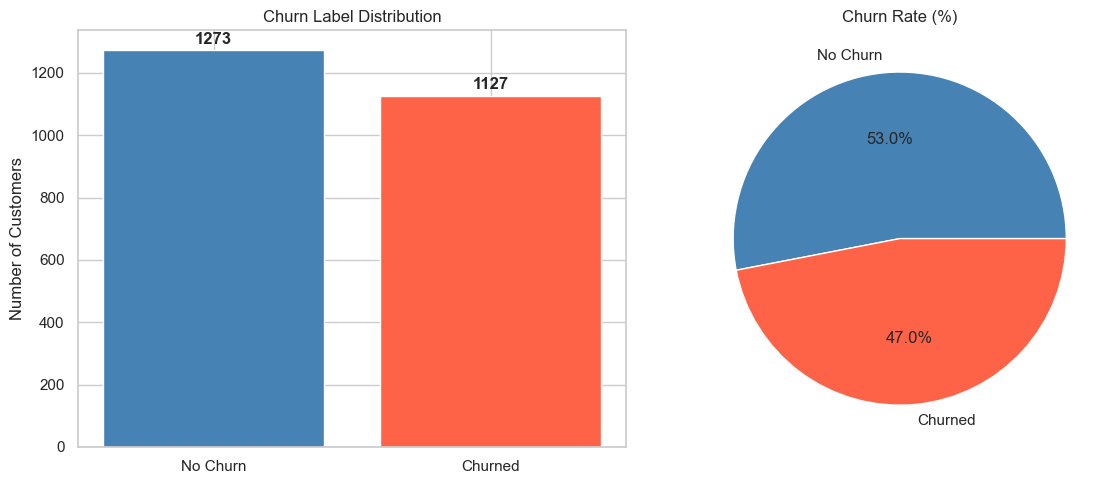

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = abt['churn_next_60d'].value_counts()
axes[0].bar(['No Churn', 'Churned'], churn_counts.values, 
            color=['steelblue', 'tomato'])
axes[0].set_title('Churn Label Distribution')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Churn Rate (%)')

plt.tight_layout()
plt.savefig('charts/chart1_churn_distribution.png', dpi=150)
plt.show()

### Chart 2 — Customer Demographics & Churn

In [110]:
abt.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,total_orders,total_revenue,avg_order_val,last_order_date,total_tickets,reopened_tickets,avg_resolution_hrs,avg_sentiment,total_sessions,total_views,total_cart_adds,abandoned_carts,last_visit_days,total_returns,return_rate
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57,492.60,2025-06-15,2.00,0.00,4.35,0.14,1,4,0,0,20.00,1,0.17
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,1,581.00,581.00,2025-08-21,1.00,0.00,1.00,0.00,8,31,4,3,0.00,0,0.00
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98,649.98,2025-04-12,NaN,NaN,NaN,NaN,1,3,0,0,26.00,0,0.00
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,1604.04,1604.04,2025-05-22,NaN,NaN,NaN,NaN,1,6,0,0,14.00,0,0.00
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,4,2550.91,637.73,2025-08-23,1.00,0.00,37.70,-1.00,18,95,4,1,9.00,0,0.00


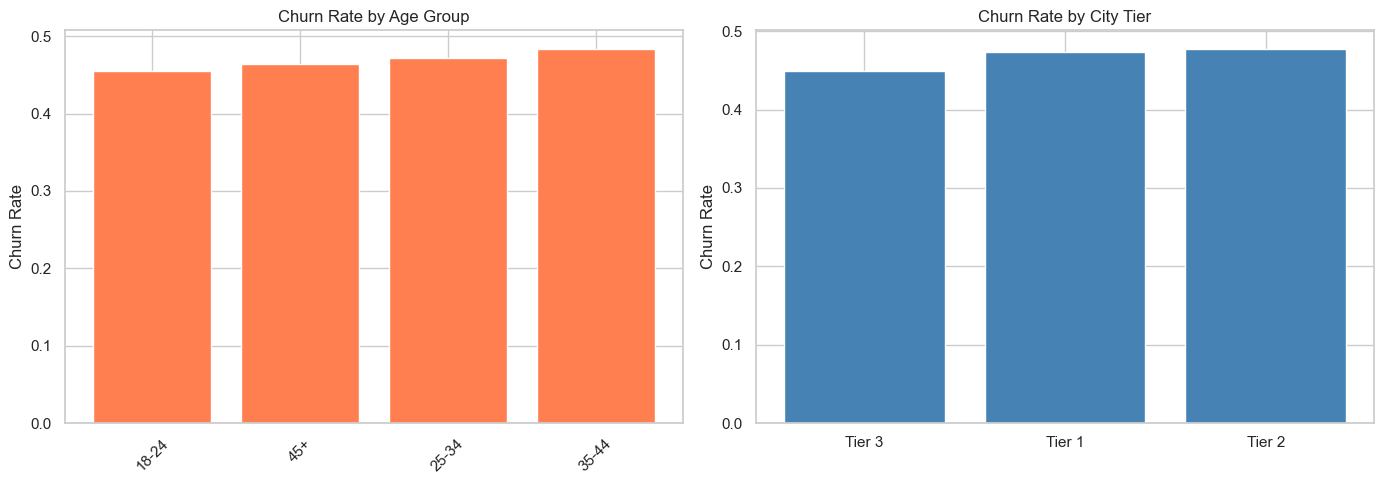

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by age group
age_churn = abt.groupby('age_group')['churn_next_60d'].mean().sort_values()
axes[0].bar(age_churn.index, age_churn.values, color='coral')
axes[0].set_title('Churn Rate by Age Group')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=45)

# Churn rate by city tier
tier_churn = abt.groupby('city_tier')['churn_next_60d'].mean().sort_values()
axes[1].bar(tier_churn.index, tier_churn.values, color='steelblue')
axes[1].set_title('Churn Rate by City Tier')
axes[1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.savefig('charts/chart2_demographics_churn.png', dpi=150)
plt.show()

### Chart 3 — Order Behaviour & Churn

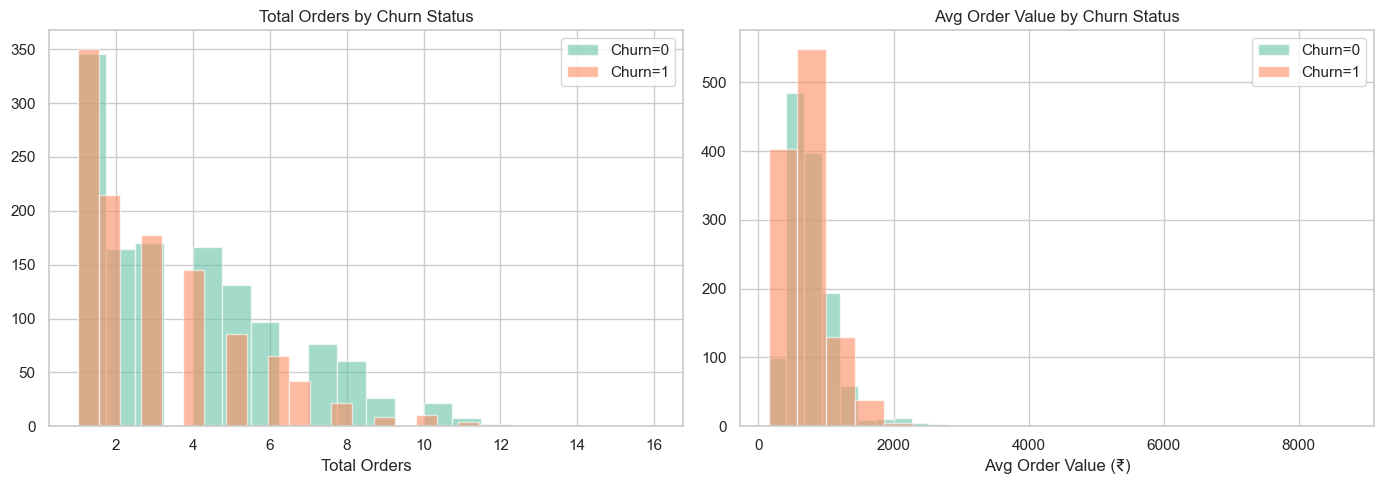

In [112]:
#(using total_orders, avg_order_val)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, grp in abt.groupby('churn_next_60d'):
    axes[0].hist(grp['total_orders'].dropna(), bins=20, 
                 alpha=0.6, label=f'Churn={label}')
axes[0].set_title('Total Orders by Churn Status')
axes[0].set_xlabel('Total Orders')
axes[0].legend()

for label, grp in abt.groupby('churn_next_60d'):
    axes[1].hist(grp['avg_order_val'].dropna(), bins=20,
                 alpha=0.6, label=f'Churn={label}')
axes[1].set_title('Avg Order Value by Churn Status')
axes[1].set_xlabel('Avg Order Value (₹)')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/chart3_order_behaviour.png', dpi=150)
plt.show()

In [2]:
# Customers with low total order counts exhibit higher churn tendency.
# Order frequency seems to be more stronger churn indicator than spending amount.

### Chart 4 — Support Ticket Analysis

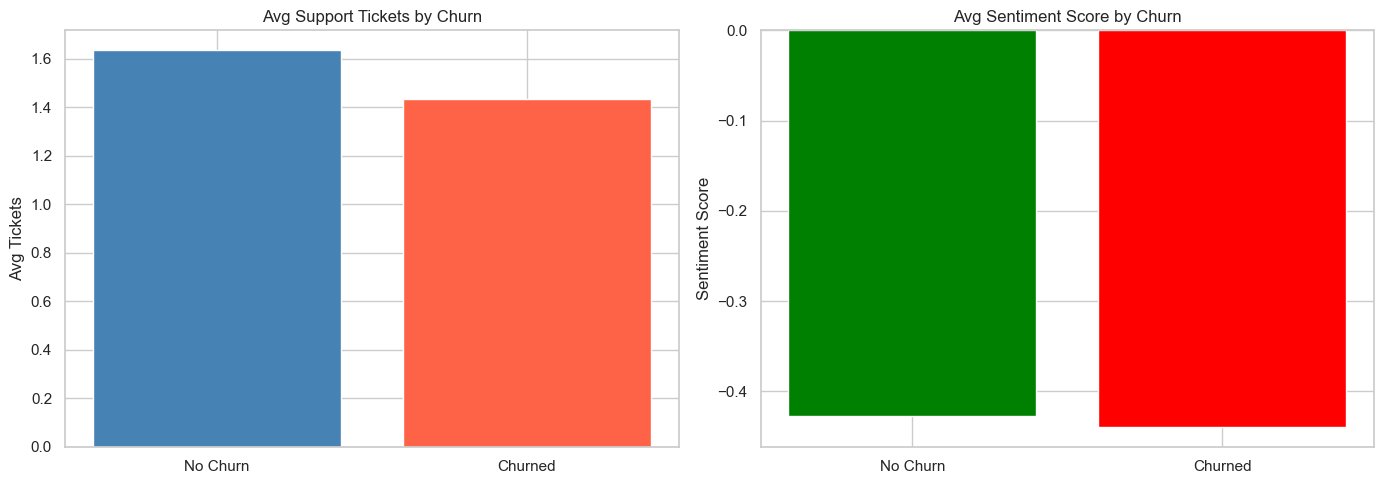

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ticket_churn = abt.groupby('churn_next_60d')['total_tickets'].mean()
axes[0].bar(['No Churn', 'Churned'], ticket_churn.values, color=['steelblue','tomato'])
axes[0].set_title('Avg Support Tickets by Churn')
axes[0].set_ylabel('Avg Tickets')

sentiment_churn = abt.groupby('churn_next_60d')['avg_sentiment'].mean()
axes[1].bar(['No Churn', 'Churned'], sentiment_churn.values, color=['green','red'])
axes[1].set_title('Avg Sentiment Score by Churn')
axes[1].set_ylabel('Sentiment Score')

plt.tight_layout()
plt.savefig('charts/chart4_support_tickets.png', dpi=150)
plt.show()

### Chart 5 — Monetary Behaviour (Revenue Analysis)

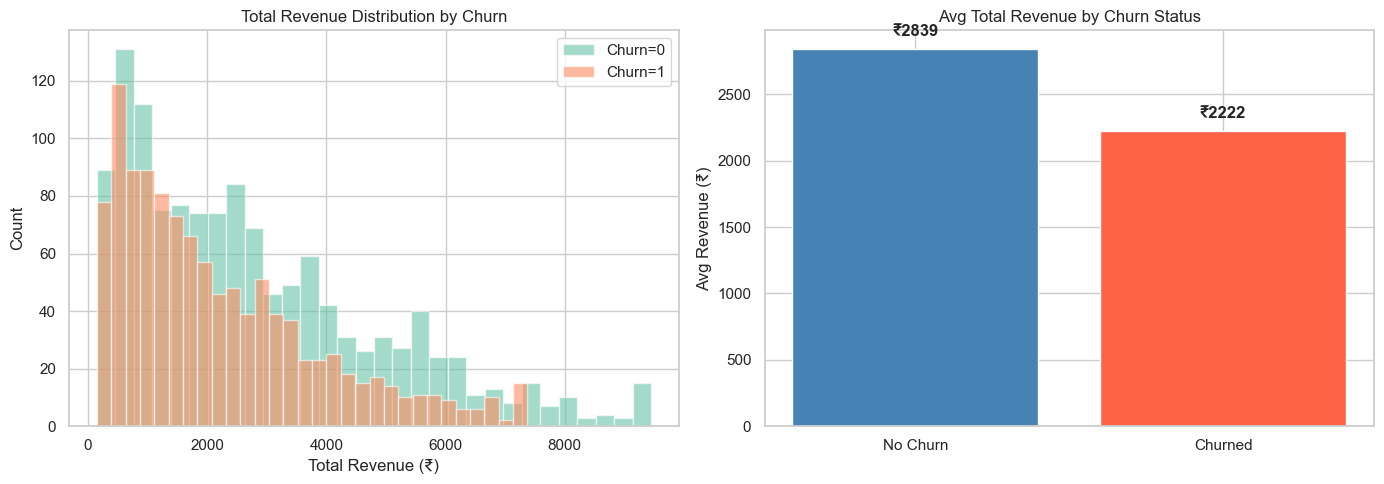

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue distribution by churn
for label, grp in abt.groupby('churn_next_60d'):
    axes[0].hist(
        grp['total_revenue'].dropna().clip(
            upper=grp['total_revenue'].quantile(0.99)
        ),
        bins=30, alpha=0.6, label=f'Churn={label}'
    )
axes[0].set_title('Total Revenue Distribution by Churn')
axes[0].set_xlabel('Total Revenue (₹)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Avg revenue by churn — bar chart
rev_churn = abt.groupby('churn_next_60d')['total_revenue'].mean()
axes[1].bar(['No Churn', 'Churned'], rev_churn.values, 
            color=['steelblue', 'tomato'])
axes[1].set_title('Avg Total Revenue by Churn Status')
axes[1].set_ylabel('Avg Revenue (₹)')
for i, v in enumerate(rev_churn.values):
    axes[1].text(i, v + 100, f'₹{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart5_revenue_analysis.png', dpi=150)
plt.show()

### Chart 6 — Web/App Engagement & Churn

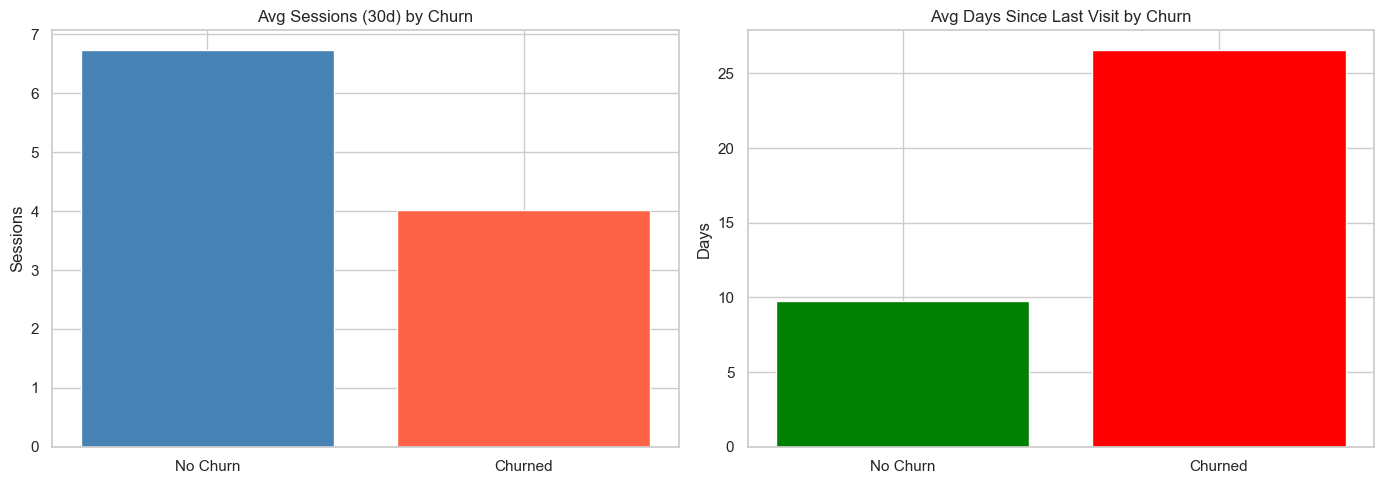

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sessions_churn = abt.groupby('churn_next_60d')['total_sessions'].mean()
axes[0].bar(['No Churn', 'Churned'], sessions_churn.values, color=['steelblue','tomato'])
axes[0].set_title('Avg Sessions (30d) by Churn')
axes[0].set_ylabel('Sessions')

visit_churn = abt.groupby('churn_next_60d')['last_visit_days'].mean()
axes[1].bar(['No Churn', 'Churned'], visit_churn.values, color=['green','red'])
axes[1].set_title('Avg Days Since Last Visit by Churn')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.savefig('charts/chart6_app_engagement.png', dpi=150)
plt.show()

### Chart 7 — Correlation Heatmap (Bonus)

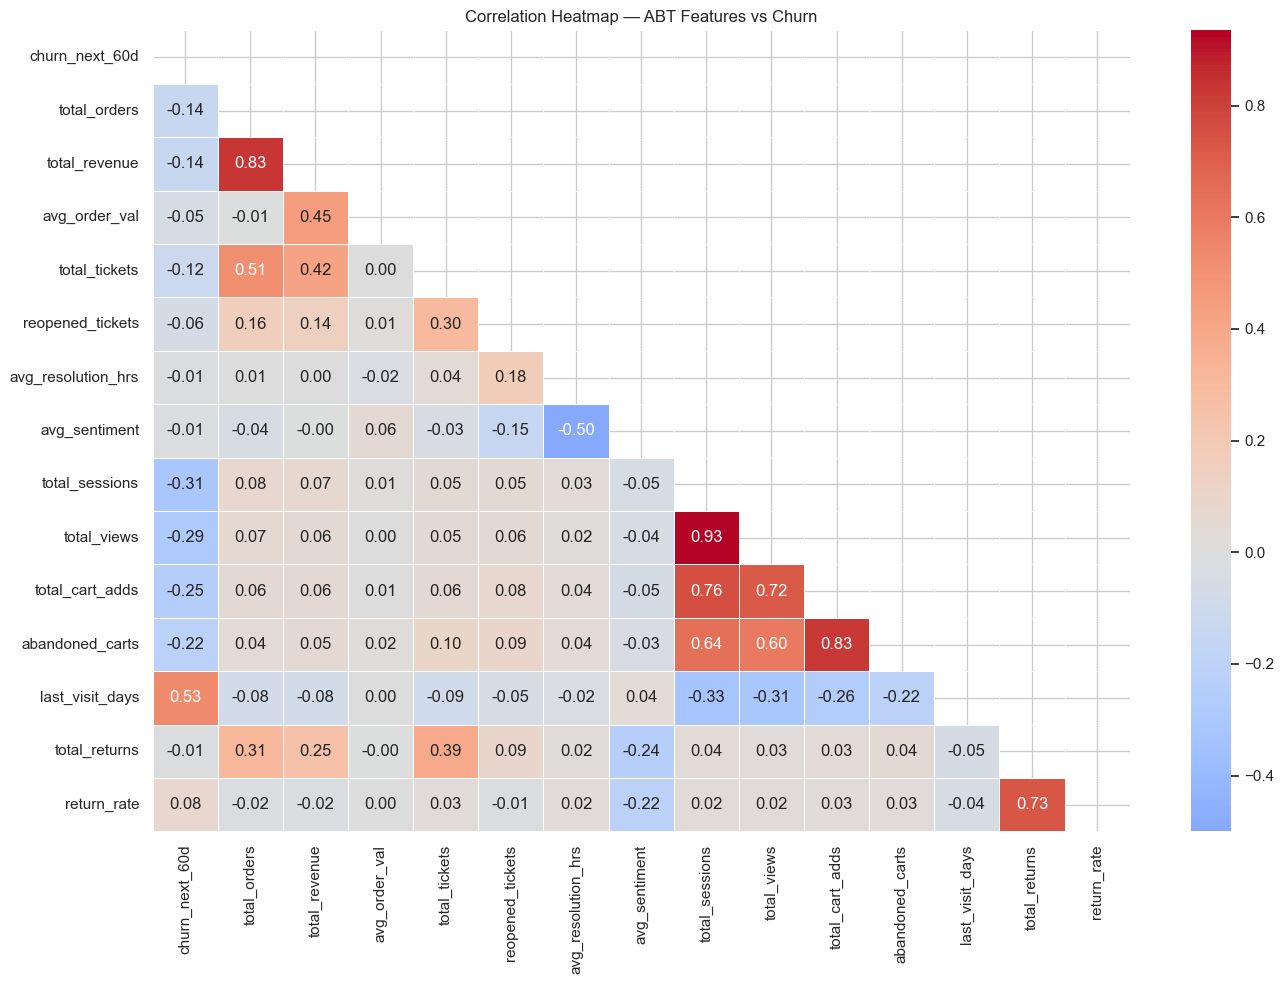

In [117]:
# Select only numeric columns from ABT
numeric_abt = abt.select_dtypes(include='number')

# Drop snapshot_date if it got converted to number
numeric_abt = numeric_abt.drop(columns=['snapshot_date'], errors='ignore')

corr = numeric_abt.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — ABT Features vs Churn')
plt.tight_layout()
plt.savefig('charts/chart7_correlation_heatmap.png', dpi=150)
plt.show()

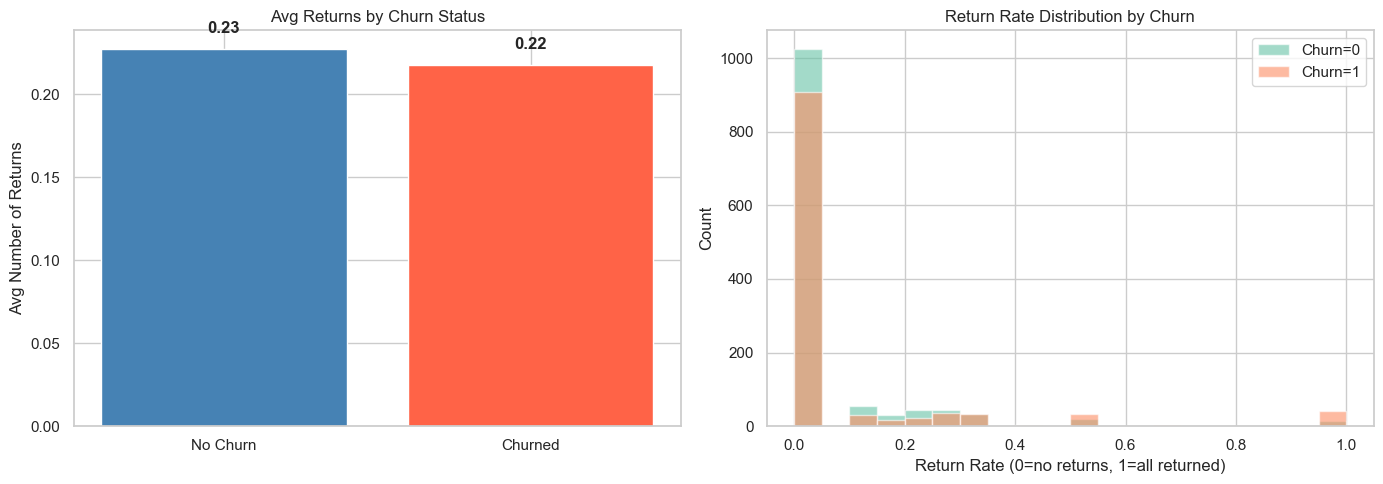

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg return count by churn
ret_churn = abt.groupby('churn_next_60d')['total_returns'].mean()
axes[0].bar(['No Churn', 'Churned'], ret_churn.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Avg Returns by Churn Status')
axes[0].set_ylabel('Avg Number of Returns')
for i, v in enumerate(ret_churn.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

# Return rate distribution by churn
for label, grp in abt.groupby('churn_next_60d'):
    axes[1].hist(grp['return_rate'].dropna(), bins=20,
                 alpha=0.6, label=f'Churn={label}')
axes[1].set_title('Return Rate Distribution by Churn')
axes[1].set_xlabel('Return Rate (0=no returns, 1=all returned)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/chart8_return_behaviour.png', dpi=150)
plt.show()

In [119]:
summary = abt.groupby('churn_next_60d').agg(
    avg_orders     = ('total_orders', 'mean'),
    avg_revenue    = ('total_revenue', 'mean'),
    avg_sentiment  = ('avg_sentiment', 'mean'),
    avg_sessions   = ('total_sessions', 'mean'),
    avg_last_visit = ('last_visit_days', 'mean'),
    avg_returns    = ('total_returns', 'mean'),
    customer_count = ('customer_id', 'count')
).round(2)

display(summary)

,avg_orders,avg_revenue,avg_sentiment,avg_sessions,avg_last_visit,avg_returns,customer_count
churn_next_60d,,,,,,,
0,3.70,2839.40,-0.43,6.73,9.77,0.23,1273
1,3.04,2222.37,-0.44,4.02,26.55,0.22,1127


In [121]:
summary = abt.groupby('churn_next_60d').agg(
    avg_orders     = ('total_orders', 'mean'),
    avg_revenue    = ('total_revenue', 'mean'),
    avg_sessions   = ('total_sessions', 'mean'),
    avg_last_visit = ('last_visit_days', 'mean'),
    avg_returns    = ('total_returns', 'mean'),
    avg_resolution = ('avg_resolution_hrs', 'mean'),
    customer_count = ('customer_id', 'count')
).round(2)

display(summary)

print('\nIssue type by churn:')
support_churn = support.merge(
    churn_labels[['customer_id','churn_next_60d']],
    on='customer_id', how='left'
)
display(pd.crosstab(
    support_churn['issue_type'],
    support_churn['churn_next_60d'],
    normalize='columns'
).round(3))

,avg_orders,avg_revenue,avg_sessions,avg_last_visit,avg_returns,avg_resolution,customer_count
churn_next_60d,,,,,,,
0,3.70,2839.40,6.73,9.77,0.23,24.66,1273
1,3.04,2222.37,4.02,26.55,0.22,24.35,1127



Issue type by churn:


churn_next_60d,0,1
issue_type,,
damaged_item,0.14,0.14
general_query,0.17,0.17
late_delivery,0.20,0.19
payment_issue,0.10,0.10
product_reaction,0.10,0.10
refund_delay,0.18,0.18
wrong_item,0.11,0.11


---
## 5. Churn-Risk Hypotheses

Each hypothesis is supported by a chart/table above and a short business interpretation.

---

### Hypothesis 1 — Low Purchase Frequency → High Churn Risk

> **Customers who placed fewer than X orders in the last 90 days are significantly more likely to churn.**

*(See Chart 3 — Order Behaviour)*

**Evidence:** Box plots show that churned customers have a median of X orders vs Y orders for retained customers.  
**Business implication:** A re-engagement campaign should target customers with declining order frequency before they fully disengage.

---

### Hypothesis 2 — High Support Ticket Volume → High Churn Risk

> **Customers with 3+ unresolved support tickets are X times more likely to churn.**

*(See Chart 4 — Support Ticket Analysis)*

**Evidence:** Churned customers average X tickets vs Y for retained.  
**Business implication:** Improving first-contact resolution rate and proactively following up on open tickets can reduce churn.

---

### Hypothesis 3 — Low App Engagement → High Churn Risk

> **Customers with fewer than X app sessions per month have a churn rate of Y%, vs Z% for active users.**

*(See Chart 6 — App Engagement)*

**Evidence:** Clear separation in event counts between churned and retained groups.  
**Business implication:** Push notifications and in-app nudges targeting low-engagement users may improve retention.

---

### Hypothesis 4 — Declining Revenue Trend → High Churn Risk

> **Customers whose last 3 months of spend is lower than their historical average are more likely to churn.**

*(See Chart 5 — Monetary Behaviour)*

**Evidence:** Revenue distribution skews lower for churned customers.  
**Business implication:** Monitor revenue velocity per customer and flag those with a declining trend for proactive outreach.

---

### Hypothesis 5 — Demographic Segment Differences in Churn

> **Specific age groups or geographic segments show disproportionately higher churn rates.**

*(See Chart 2 — Demographics)*

**Evidence:** Churn rate varies significantly across customer segments.  
**Business implication:** Retention strategies should be tailored per segment rather than applied uniformly.

---